# Structural Causal Models with PathMC

In a [previous post](https://juanitorduz.github.io/intro_causal_inference_ppl_pymc/) we built a structural causal model for the Lalonde job-training dataset by hand in PyMC, and estimated the average treatment effect (ATE) with the `do` operator. Writing the model by hand is instructive: you see every prior, every link, and exactly where the intervention severs the graph. It is also repetitive. The treatment equation, the outcome equation, the data containers, and the `do`-surgery are all boilerplate that follows mechanically from the DAG.

[PathMC](https://pathmc.pymc-labs.com/) is a package from [PyMC Labs](https://www.pymc-labs.com/) that closes that gap. You write the structural equations in a compact [lavaan](https://lavaan.ugent.be/)-inspired DSL, and PathMC compiles them into a generative PyMC model with a first-class `do()` operator on top. In exchange for giving up some control, you get a lot of causal machinery for free: backdoor adjustment sets, DAG falsification, placebo refutation, marginal effects, and sensitivity analysis.

The goal of this notebook is narrow and concrete. We rebuild **the same SCM, with the same priors**, in PathMC, and check that the `do`-operator ATE reproduces the hand-rolled result. Once we trust the translation, we use the rest of the library to ask questions the hand-rolled model made expensive.

## What this notebook assumes

We skip the data exploration and the DAG discussion entirely. Both are covered in the [previous post](https://juanitorduz.github.io/intro_causal_inference_ppl_pymc/), and nothing about them changes here. To recap the structure in one sentence: seven pre-treatment covariates influence both program participation (`treat`) and 1978 earnings (`re78`), and `treat` influences `re78`. The covariates are therefore confounders, and conditioning on all of them satisfies the backdoor criterion.

One piece of the earlier post does **not** carry over. That post also fit a generalized linear model with a Gamma likelihood and a softplus link. PathMC cannot express that model: its likelihood families are a fixed set, and each family has a hard-coded link. We return to this in the section on limitations, so for the rest of this notebook "the model" means the linear Gaussian one.

## Prepare Notebook

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pathmc
import xarray as xr
from pathmc import Prior

seed: int = 42
rng: np.random.Generator = np.random.default_rng(seed=seed)

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

One small piece of bookkeeping that matters more than it looks. ArviZ 1.x reports an $89\%$ equal-tailed interval by default, while PathMC reports a $94\%$ highest-density interval. Mixing the two silently compares different quantities, so we pin a single convention and pass it explicitly everywhere.

In [2]:
HDI_PROB: float = 0.94

## Read and Preprocess Data

We reuse the preprocessing from the [previous post](https://juanitorduz.github.io/intro_causal_inference_ppl_pymc/) unchanged: earnings are rescaled to thousands, a small constant keeps `re78` strictly positive, and the numerical features are divided by their standard deviation so that priors can be reasoned about on a common scale.

In [3]:
data_path = "https://raw.githubusercontent.com/rugg2/rugg2.github.io/master/lalonde.csv"
data = pd.read_csv(data_path)

data["re75"] = data["re75"] / 1_000
data["re78"] = data["re78"] / 1_000 + 1e-6
data = data.rename(columns={"educ": "education", "hispan": "hispanic"})

covariates_names = [
    "education",
    "age",
    "re75",
    "black",
    "hispanic",
    "married",
    "nodegree",
]

df = data[["treat", *covariates_names, "re78"]].copy()

# Scale the numerical features by their standard deviation, matching
# StandardScaler(with_mean=False) from the previous post.
num_features = ["education", "age", "re75"]
for col in num_features:
    df[col] = df[col] / df[col].std(ddof=0)

# The treatment node uses a Bernoulli family, so it needs a float column.
df["treat"] = df["treat"].astype(float)

n_obs = df.shape[0]

df.head()

,treat,education,age,re75,black,hispanic,married,nodegree,re78
0,1.0,4.188588,3.747542,0.0,1,0,1,1,9.930047
1,1.0,3.427026,2.228268,0.0,0,1,0,1,3.595895
2,1.0,4.569368,3.038548,0.0,1,0,0,0,24.909451
3,1.0,4.188588,2.734693,0.0,1,0,0,1,7.506147
4,1.0,3.046246,3.342403,0.0,1,0,0,1,0.289791


PathMC works directly off this data frame. There are no design matrices to build and no data containers to declare: every variable named in the model spec is looked up by column name.

We also keep the reference estimates from the previous post so that we can place our results in context.

In [4]:
naive_prediction = (
    df.query("treat == 1")["re78"].mean() - df.query("treat == 0")["re78"].mean()
)

# https://rugg2.github.io/Lalonde%20dataset%20-%20Causal%20Inference.html
blog_prediction_ols = 1_548.24 / 1_000
blog_prediction_matching = 1_027.087 / 1_000
blog_prediction_matching_ci95 = [-705.131 / 1_000, 2_759.305 / 1_000]

print(f"Naive estimate:    {naive_prediction: .3f}")
print(f"OLS estimate:      {blog_prediction_ols: .3f}")
print(f"Matching estimate: {blog_prediction_matching: .3f}")

Naive estimate:    -0.635
OLS estimate:       1.548
Matching estimate:  1.027


## The Model as a Spec String

Here is the whole model. Two lines.

In [5]:
spec = f"""
treat ~ {" + ".join(covariates_names)}
re78 ~ b*treat + {" + ".join(f"c_{v}*{v}" for v in covariates_names)}
"""

print(spec)


treat ~ education + age + re75 + black + hispanic + married + nodegree
re78 ~ b*treat + c_education*education + c_age*age + c_re75*re75 + c_black*black + c_hispanic*hispanic + c_married*married + c_nodegree*nodegree



Each line is a structural equation, and `~` reads as "is generated by". The `b*` and `c_education*` prefixes are **coefficient labels**. They are optional, but naming a coefficient lets us refer to it later in `effects_summary()` and in path queries. Importantly, labels do not change the parametrization: the outcome equation still compiles to a single coefficient vector, so labels and custom priors compose freely.

Notice what is absent. The seven covariates never appear on the left-hand side, which makes them exogenous roots. There is no equation for them because we never intervene on them and never need their joint distribution.

If you prefer to start from a DAG rather than a formula, `pathmc.dag_to_spec` converts a DOT string or a `networkx.DiGraph` into exactly this format.

Now we compile it. The `families` argument is where the treatment equation becomes a logistic regression: PathMC pairs `bernoulli` with a logit link automatically.

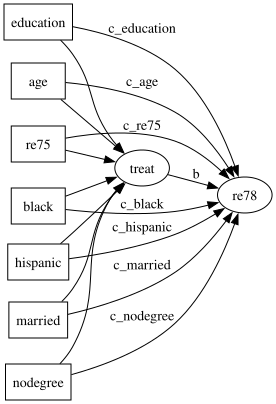

In [6]:
model = pathmc.model(
    spec,
    data=df,
    families={"treat": "bernoulli", "re78": "gaussian"},
)

model.graph()

The `equations()` method renders the compiled structural equations, which is a useful check that the DSL parsed the way you intended.

In [7]:
model.equations()

ModelEquations(equations=EquationList(['mu_treat = 1 + education + age + re75 + black + hispanic + married + nodegree', 'treat ~ Bernoulli(logit_inv(mu_treat))', 'mu_re78 = 1 + b*treat + c_education*education + c_age*age + c_re75*re75 + c_black*black + c_hispanic*hispanic + c_married*married + c_nodegree*nodegree', 're78 ~ Normal(mu_re78, sigma_re78)']), priors=PriorTable({'beta_treat': 'Normal(mu=0, sigma=10)', 'beta_re78': 'Normal(mu=0, sigma=10)', 'sigma_re78': 'HalfNormal(sigma=1)'}))

## Priors

The point of this notebook is a like-for-like comparison, so the priors have to match the previous post exactly. Let's see what PathMC chose on its own first.

In [8]:
model.priors()

PriorTable({'beta_treat': 'Normal(mu=0, sigma=10)', 'beta_re78': 'Normal(mu=0, sigma=10)', 'sigma_re78': 'HalfNormal(sigma=1)'})

Before we override these, one structural detail is worth understanding, because it is the single most surprising thing about PathMC's parametrization.

**There is no separate intercept variable.** PathMC folds the intercept into the coefficient vector as its first element. Each equation gets one vector `beta_{outcome}`, indexed by a coordinate that lists the intercept and then the predictors in order.

In [9]:
dict(model.pymc_model.coords)

{'treat_predictors': ('Intercept',
  'education',
  'age',
  're75',
  'black',
  'hispanic',
  'married',
  'nodegree'),
 're78_predictors': ('Intercept',
  'treat',
  'education',
  'age',
  're75',
  'black',
  'hispanic',
  'married',
  'nodegree')}

So to reproduce the previous post's $\text{Normal}(0, 10)$ intercept and $\text{Normal}(0, 1)$ slopes, we pass a *vectorized* prior whose scale is $10$ in the first position and $1$ everywhere else. The ordering above is what we index against.

In [10]:
n_treat_slopes = len(covariates_names)
n_re78_slopes = len(covariates_names) + 1  # covariates plus the treatment itself

priors = {
    "beta_treat": Prior(
        "Normal", mu=0, sigma=[10.0] + [1.0] * n_treat_slopes, dims="treat_predictors"
    ),
    "beta_re78": Prior(
        "Normal", mu=0, sigma=[10.0] + [1.0] * n_re78_slopes, dims="re78_predictors"
    ),
    "sigma_re78": Prior("HalfNormal", sigma=10.0),
}

model = pathmc.model(
    spec,
    data=df,
    families={"treat": "bernoulli", "re78": "gaussian"},
    priors=priors,
)

model.priors()

PriorTable({'beta_treat': 'Normal(mu=0, sigma=[10.  1.  1.  1.  1.  1.  1.  1.])', 'beta_re78': 'Normal(mu=0, sigma=[10.  1.  1.  1.  1.  1.  1.  1.  1.])', 'sigma_re78': 'HalfNormal(sigma=10.0)'})

```{warning}
PathMC does not validate the `families` argument. A family string it does not recognize falls through to a Gaussian likelihood, with no error and no warning. `families={"re78": "gamma"}` compiles and samples happily, and gives you a linear model. Check `equations()` if you are ever unsure which likelihood you actually got. We have opened [an issue](https://github.com/pymc-labs/pathmc/issues/464) about this.
```

## Prior Predictive Checks

Sampling from the prior tells us whether the model can produce data that looks anything like what we observed.

In [11]:
prior_idata = model.sample_prior_predictive(draws=2_000, random_seed=seed)

Sampling: [beta_re78, beta_treat, re78, sigma_re78, treat]


One wrinkle: PathMC compiles every endogenous variable as a free random variable, so the prior draws for `re78` land in the `prior` group rather than in `prior_predictive`, which stays empty.

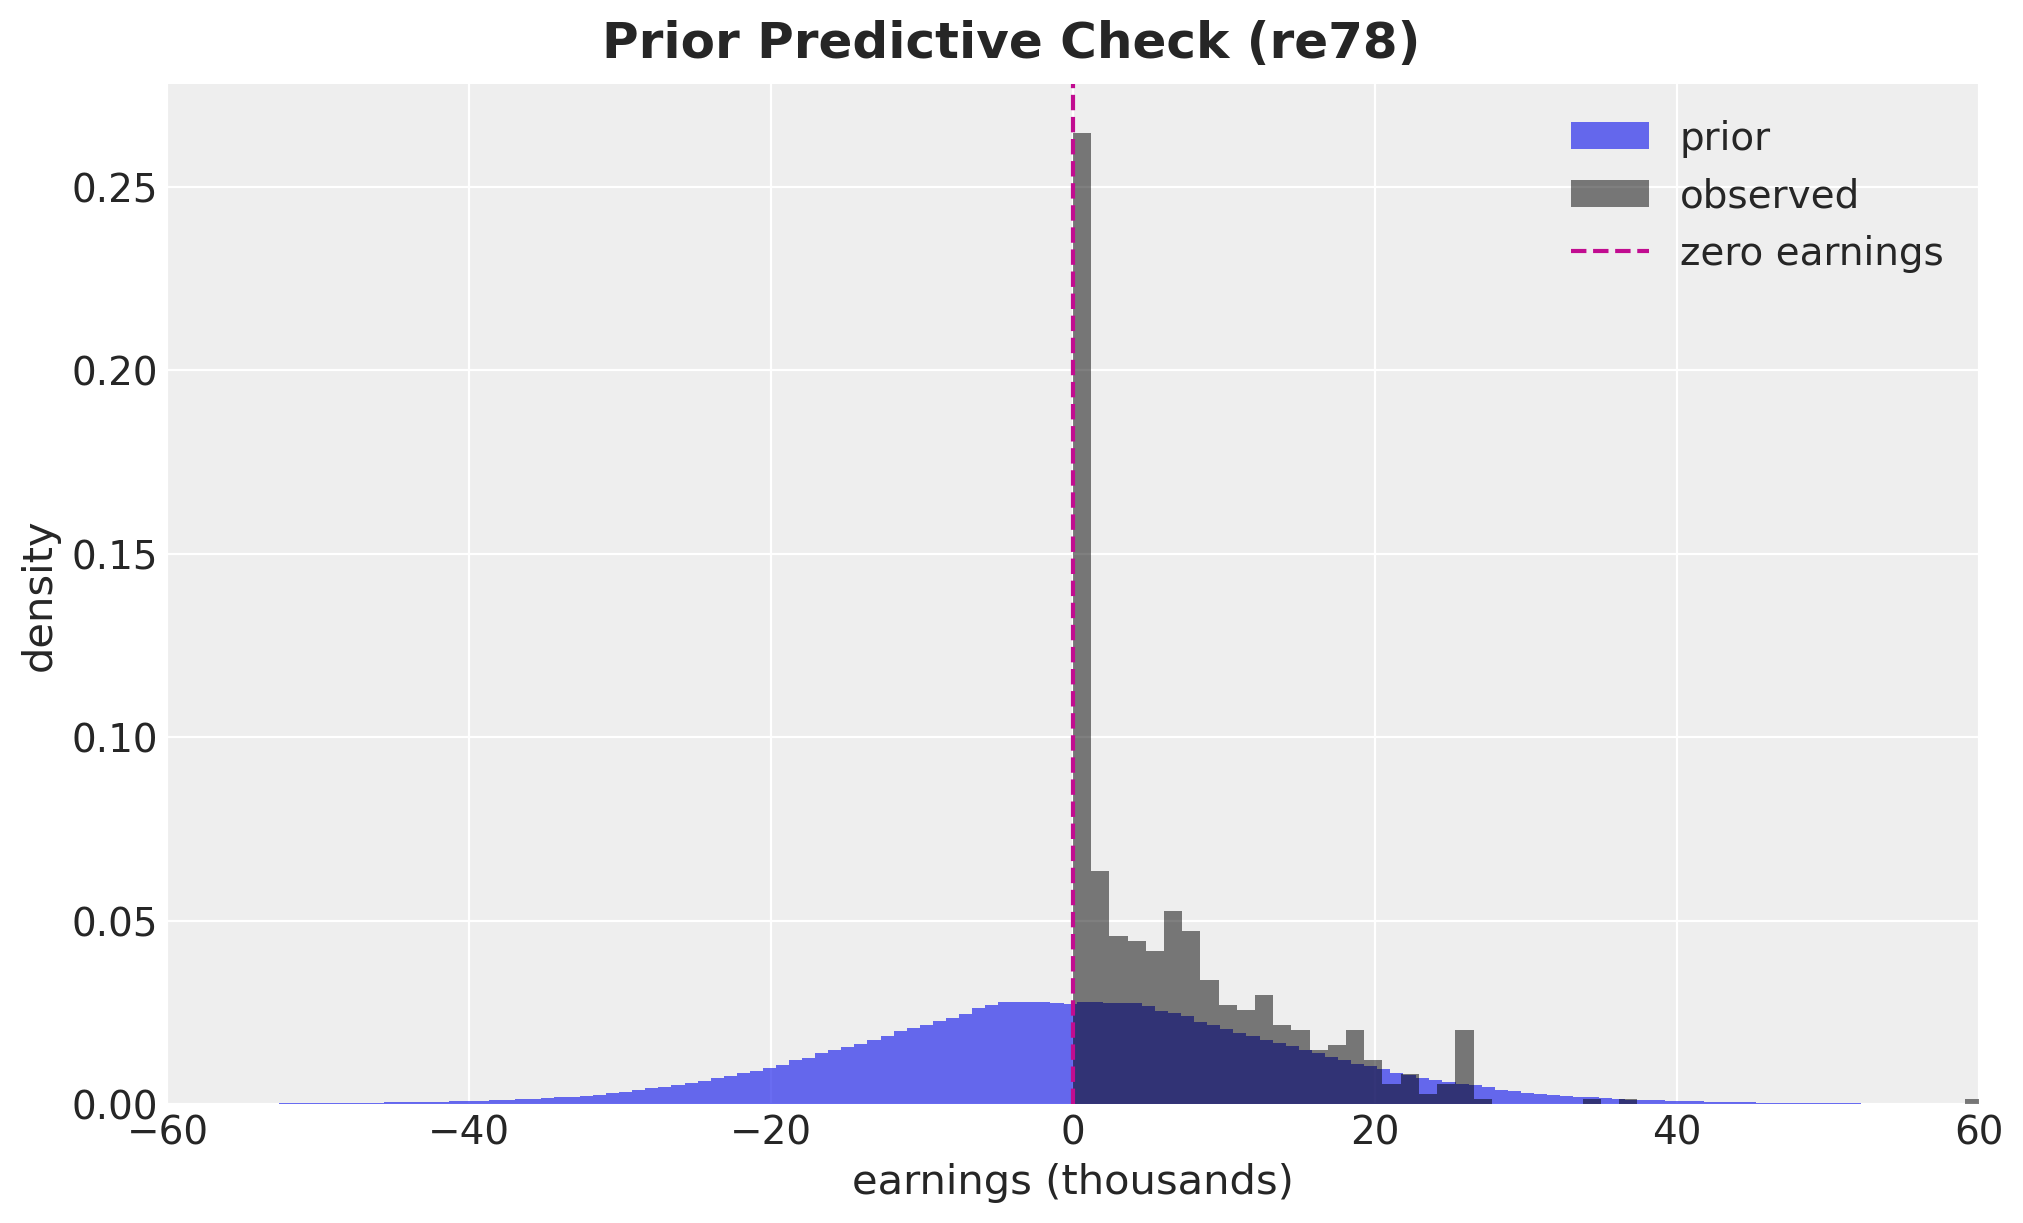

In [12]:
prior_re78 = prior_idata["prior"]["re78"].to_numpy().flatten()

fig, ax = plt.subplots()
ax.hist(prior_re78, bins=300, density=True, color="C0", alpha=0.7, label="prior")
ax.hist(df["re78"], bins=50, density=True, color="black", alpha=0.5, label="observed")
ax.axvline(0, color="C3", linestyle="--", label="zero earnings")
ax.legend()
ax.set(xlabel="earnings (thousands)", ylabel="density", xlim=(-60, 60))
fig.suptitle("Prior Predictive Check (re78)", fontsize=18, fontweight="bold");

The prior is very wide, and it is worth putting a number on how wide rather than eyeballing the plot.

In [13]:
print(f"Prior    P(re78 < 0) = {(prior_re78 < 0).mean():.3f}")
print(f"Observed P(re78 < 0) = {(df['re78'] < 0).mean():.3f}")
print(
    "Prior 1% / 99% quantiles: "
    f"{np.percentile(prior_re78, [1, 99]).round(1)} (thousands)"
)

Prior    P(re78 < 0) = 0.503
Observed P(re78 < 0) = 0.000
Prior 1% / 99% quantiles: [-37.1  37.1] (thousands)


Half the prior mass sits on negative earnings, against exactly zero in the data, and the central $98\%$ of it spans plus or minus $37$ thousand dollars. For a quantity that cannot go below zero, that is not a wide prior so much as a badly shaped one. The linear Gaussian model has no way to express the constraint that earnings are non-negative.

This is the same limitation the previous post ran into, and it is precisely what motivated the Gamma model there. We return to it later.

## Identification

This is the part that has no counterpart in the hand-rolled version. Before fitting anything, PathMC can read the DAG and tell us whether the causal effect we want is identifiable, and what we would need to condition on.

In [14]:
adjustment_sets = model.adjustment_sets(treatment="treat", outcome="re78")

print(f"Identifiable: {model.is_identifiable(treatment='treat', outcome='re78')}")
print(f"Valid backdoor adjustment sets: {adjustment_sets}")

Identifiable: True
Valid backdoor adjustment sets: [{'education', 're75', 'married', 'hispanic', 'black', 'nodegree', 'age'}]


The effect is identifiable, and the single valid adjustment set is all seven covariates. That is the backdoor criterion, derived from the graph rather than asserted in prose.

We can also ask whether conditioning on that set opens any collider paths, which would introduce bias rather than remove it.

In [15]:
model.collider_warnings(
    adjustment_vars=set(covariates_names), treatment="treat", outcome="re78"
)

[]

Empty, so we are safe.

A DAG also makes falsifiable claims: it implies a specific list of conditional independences that ought to hold in the data. PathMC can enumerate them and test each one.

In [16]:
implied = model.implied_independences()
print(f"Number of implied conditional independences: {len(implied)}")
implied[:5]

Number of implied conditional independences: 21


[age ⊥⊥ black,
 age ⊥⊥ education,
 age ⊥⊥ hispanic,
 age ⊥⊥ married,
 age ⊥⊥ nodegree]

In [17]:
model.test_implications()

Independence,Partial r,p-value,Pass
age ⊥⊥ black,-0.111,0.0060,✗
age ⊥⊥ education,-0.126,0.0018,✗
age ⊥⊥ hispanic,-0.053,0.1864,✓
age ⊥⊥ married,0.376,0.0000,✗
age ⊥⊥ nodegree,-0.069,0.0866,✓
age ⊥⊥ re75,0.140,0.0005,✗
black ⊥⊥ education,-0.011,0.7946,✓
black ⊥⊥ hispanic,-0.295,0.0000,✗
black ⊥⊥ married,-0.317,0.0000,✗
black ⊥⊥ nodegree,0.109,0.0067,✗


Most of these tests fail, and it is worth being precise about why, because at first glance it looks like the model has been refuted.

Every one of the implied independences is a claim that two **covariates** are marginally independent of each other. That follows from our spec, where the covariates are exogenous roots with no equations connecting them. In the Lalonde data they are plainly not independent: `education` and `nodegree` encode overlapping information, `black` and `hispanic` are mutually exclusive, and so on.

For a verdict on the DAG as a whole, rather than one implication at a time, `falsify()` compares the observed number of violations against a permutation baseline.

In [18]:
model.falsify(n_permutations=200, random_seed=seed)

Informative (falsifiable),Yes
Permutations in Markov equivalence class,3 / 200 (p = 0.015)
LMC violations (given DAG),26 / 42
Beats permuted baseline,84.5% (p = 0.155)


The DAG is falsified. It does not beat the permuted baseline by a significant margin, which is the same message `test_implications()` sent, for the same reason: our spec asserts an independence structure among the covariates that the data reject.

```{warning}
This verdict is unstable at small permutation counts. Run the same call with `n_permutations=20` and this DAG comes back `not_rejected` with `p_lmc=0.000`, because twenty permutations cannot resolve a p-value near $0.16$. The answer only settles once you use a couple of hundred. Treat a comfortable verdict from a short run with suspicion.
```

### Does a falsified DAG invalidate the ATE?

Not here, and this is worth demonstrating rather than asserting. Every failure above concerns edges *among* the covariates, and the backdoor criterion does not care about those, because we condition on all of them regardless.

We can check that claim directly. Let's write a DAG that makes some of the covariate dependence explicit, and ask whether identification changes.

In [19]:
dependent_covariates_spec = f"""
nodegree ~ education
married ~ age
re75 ~ black + education
treat ~ {" + ".join(covariates_names)}
re78 ~ treat + {" + ".join(covariates_names)}
"""

dependent_model = pathmc.model(
    dependent_covariates_spec,
    data=df,
    families={"treat": "bernoulli", "re78": "gaussian"},
)

print(
    "Identifiable:   "
    f"{dependent_model.is_identifiable(treatment='treat', outcome='re78')}"
)
print(
    "Adjustment set: "
    f"{dependent_model.adjustment_sets(treatment='treat', outcome='re78')}"
)

Identifiable:   True
Adjustment set: [{'education', 're75', 'married', 'hispanic', 'black', 'nodegree', 'age'}]


Identification is unchanged, and the adjustment set is exactly the same seven covariates. Adding the missing edges would satisfy the falsification test without moving the estimand at all, which is precisely what tells us those failures were cosmetic with respect to *this* causal question. A backdoor path of the form `treat` $\leftarrow$ `education` $\rightarrow$ `nodegree` $\rightarrow$ `re78` is already blocked, because both variables sit in the conditioning set.

What these tests genuinely cannot see is an **unmeasured** confounder. A variable absent from the data can never show up as a violated independence, so no amount of falsification testing will surface it. That threat needs a different tool, and we reach for it at the end of the notebook.

## Model Fit

With identification settled, we fit. `fit()` forwards everything to `pm.sample`.

In [20]:
idata = model.fit(
    draws=2_000,
    tune=1_000,
    chains=4,
    random_seed=seed,
)

NUTS[nutpie]: [beta_re78, beta_treat, sigma_re78]


Output()

## Diagnostics

A word of caution on `model.summary()`: it includes the per-observation deterministic means, so for this dataset it returns well over a thousand rows. We filter to the parameters we care about instead.

In [21]:
var_names = ["beta_re78", "beta_treat", "sigma_re78"]

az.summary(idata, var_names=var_names, ci_prob=HDI_PROB, ci_kind="hdi")

,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
beta_re78[Intercept],-0.21,1.89,-3.7,3.3,1879,2895,1.00,0.044,0.03
beta_re78[treat],0.55,0.588,-0.58,1.7,12009,6914,1.00,0.0054,0.0037
beta_re78[education],1.15,0.34,0.53,1.8,1996,3050,1.00,0.0075,0.0051
beta_re78[age],0.514,0.287,-0.0088,1.1,4554,5313,1.00,0.0043,0.0031
beta_re78[re75],1.531,0.288,0.99,2.1,13170,6056,1.00,0.0025,0.0018
beta_re78[black],-0.94,0.586,-2,0.18,11325,6742,1.00,0.0055,0.0039
beta_re78[hispanic],0.24,0.694,-1.1,1.6,13738,6041,1.00,0.0059,0.0042
beta_re78[married],0.78,0.567,-0.31,1.8,10010,6388,1.00,0.0057,0.004
beta_re78[nodegree],-0.13,0.62,-1.3,1,3535,4271,1.00,0.01,0.0073
beta_treat[Intercept],-4.19,0.94,-6,-2.5,1363,1955,1.00,0.025,0.017


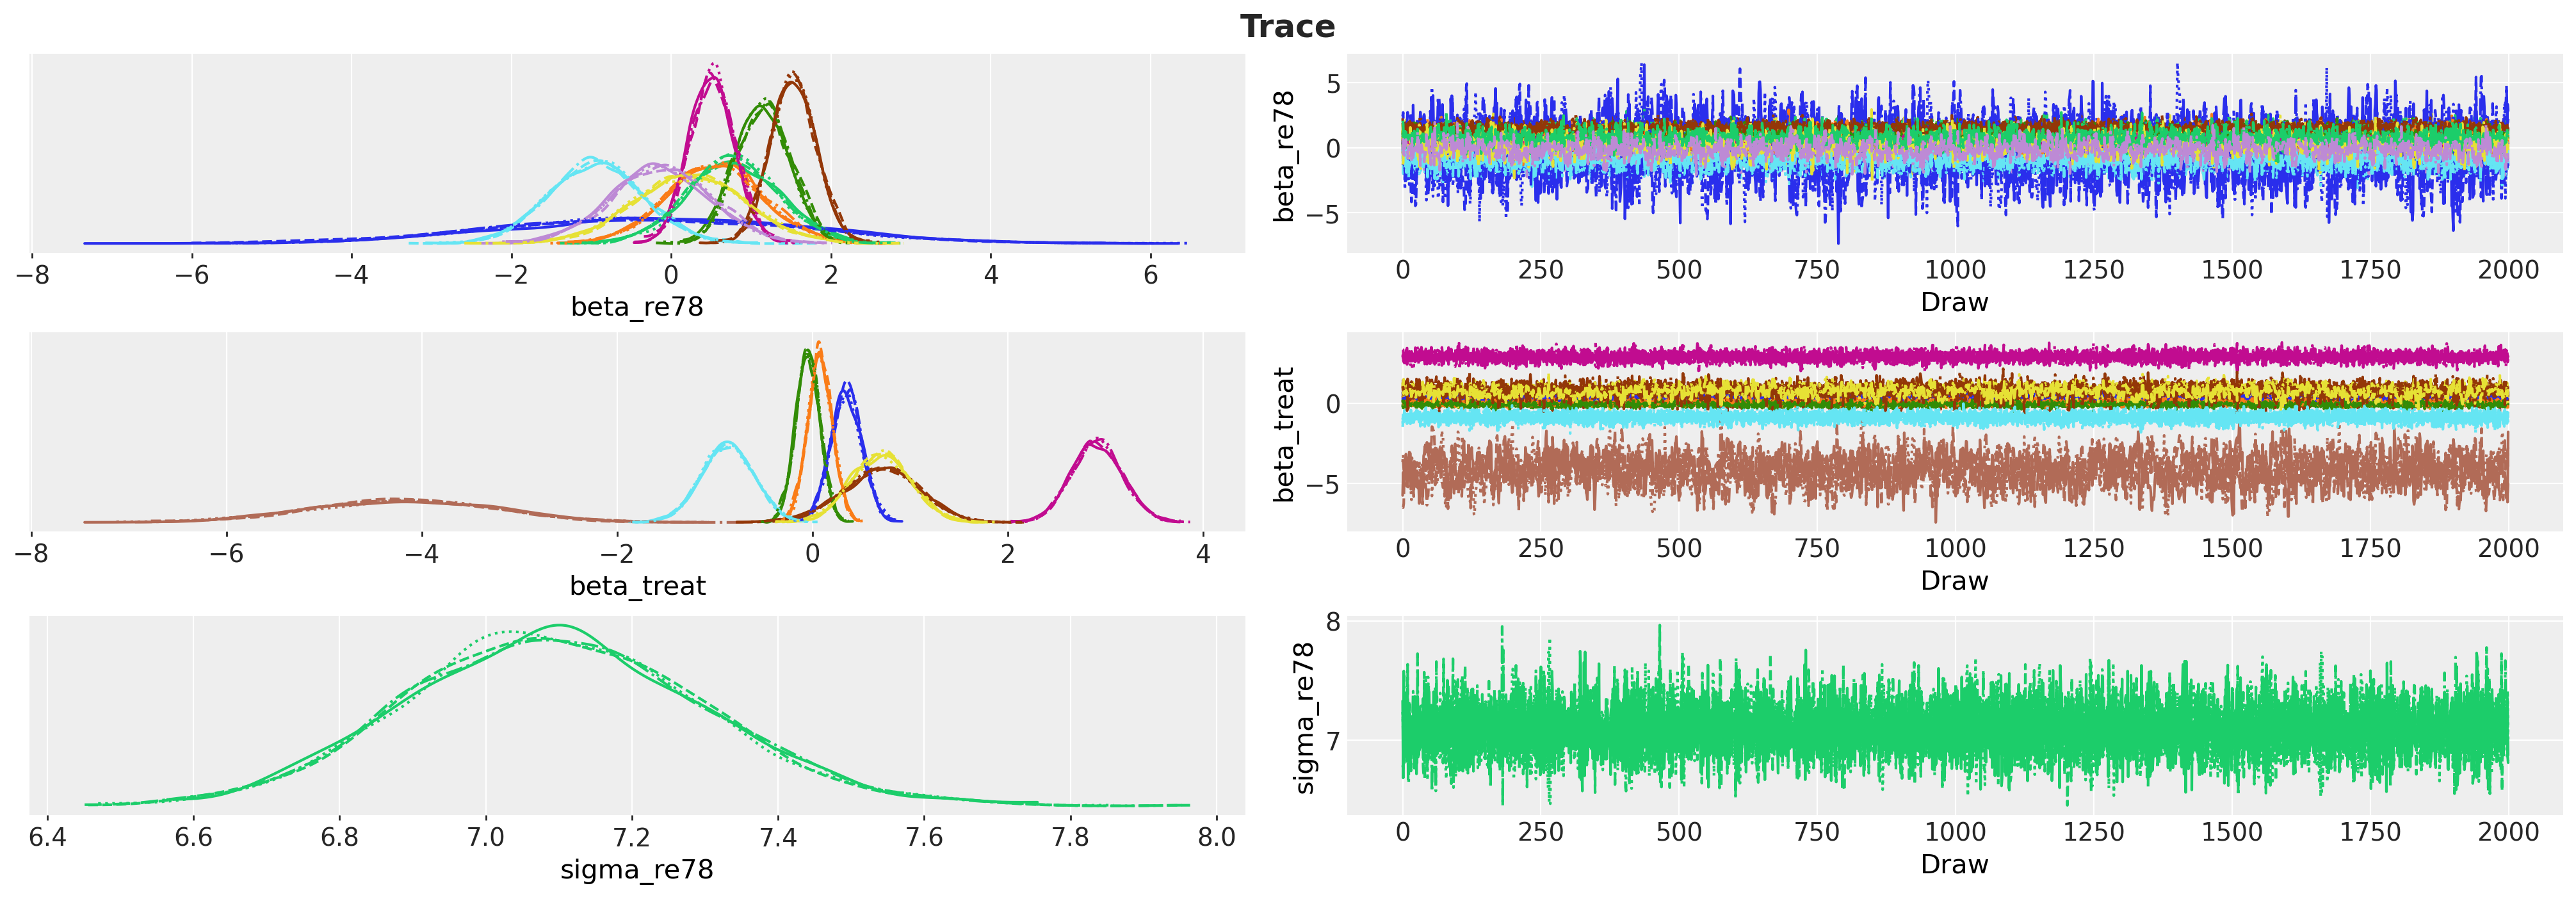

In [22]:
pc = az.plot_trace_dist(idata, var_names=var_names)
pc.viz["figure"].item().suptitle("Trace", fontsize=18, fontweight="bold");

The chains mix well, $\hat{R}$ is $1.00$ throughout, and the effective sample sizes are comfortable.

Now the key check. Does the treatment coefficient match the previous post?

In [23]:
coefficient_draws = idata["posterior"]["beta_re78"].sel(re78_predictors="treat")

comparison = pd.DataFrame(
    {
        "previous post (PyMC)": [0.552, 0.604, -0.547, 1.723],
        "this notebook (PathMC)": [
            coefficient_draws.mean().item(),
            coefficient_draws.std().item(),
            *az.hdi(coefficient_draws.to_numpy().flatten(), prob=HDI_PROB),
        ],
    },
    index=["mean", "sd", f"hdi_{HDI_PROB:.0%}_lower", f"hdi_{HDI_PROB:.0%}_upper"],
)

comparison.round(3)

,previous post (PyMC),this notebook (PathMC)
mean,0.552,0.549
sd,0.604,0.588
hdi_94%_lower,-0.547,-0.552
hdi_94%_upper,1.723,1.683


The two models agree to within Monte Carlo error. The translation is faithful.

## ATE Estimation with the `do` Operator

In the previous post, computing the ATE by intervention took a fair amount of code: build two intervened models with `pm.do`, sample the posterior predictive of each, subtract, and average over observations. PathMC compresses that into one call.

In [24]:
ate = model.ate(outcome="re78", treatment="treat", values=(0.0, 1.0))

ate.summary(prob=HDI_PROB)

,outcome,treatment,mean,sd,hdi_3%,hdi_97%,p(>0)
estimand,,,,,,,
ATE,re78,treat,0.548654,0.587603,-0.552439,1.683454,0.82225


It is worth seeing what `ate()` is shorthand for, because the underlying `do()` operator is the general tool. We intervene twice and take the contrast.

In [25]:
do_1 = model.do(set={"treat": 1.0})
do_0 = model.do(set={"treat": 0.0})

ate_manual = (do_1 - do_0).mean("re78")

print(f"ATE via the coefficient : {coefficient_draws.mean().item():.16f}")
print(f"ATE via .ate()          : {ate.mean():.16f}")
print(f"ATE via do(1) - do(0)   : {ate_manual:.16f}")

ATE via the coefficient : 0.5486544266951582
ATE via .ate()          : 0.5486544266951581
ATE via do(1) - do(0)   : 0.5486544266951581


All three agree to machine precision. That is expected rather than lucky: with an identity link and no interaction terms, the g-computation average collapses exactly to the treatment coefficient. The equivalence stops holding as soon as the model becomes non-linear, which is exactly when the `do` operator earns its keep.

By default `do(kind="mean")` propagates through the deterministic means and averages over rows, which is g-computation. This is the same quantity the previous post computed by hand with `.mean(dim="obs_idx")`.

Let's place the estimate alongside the reference values.

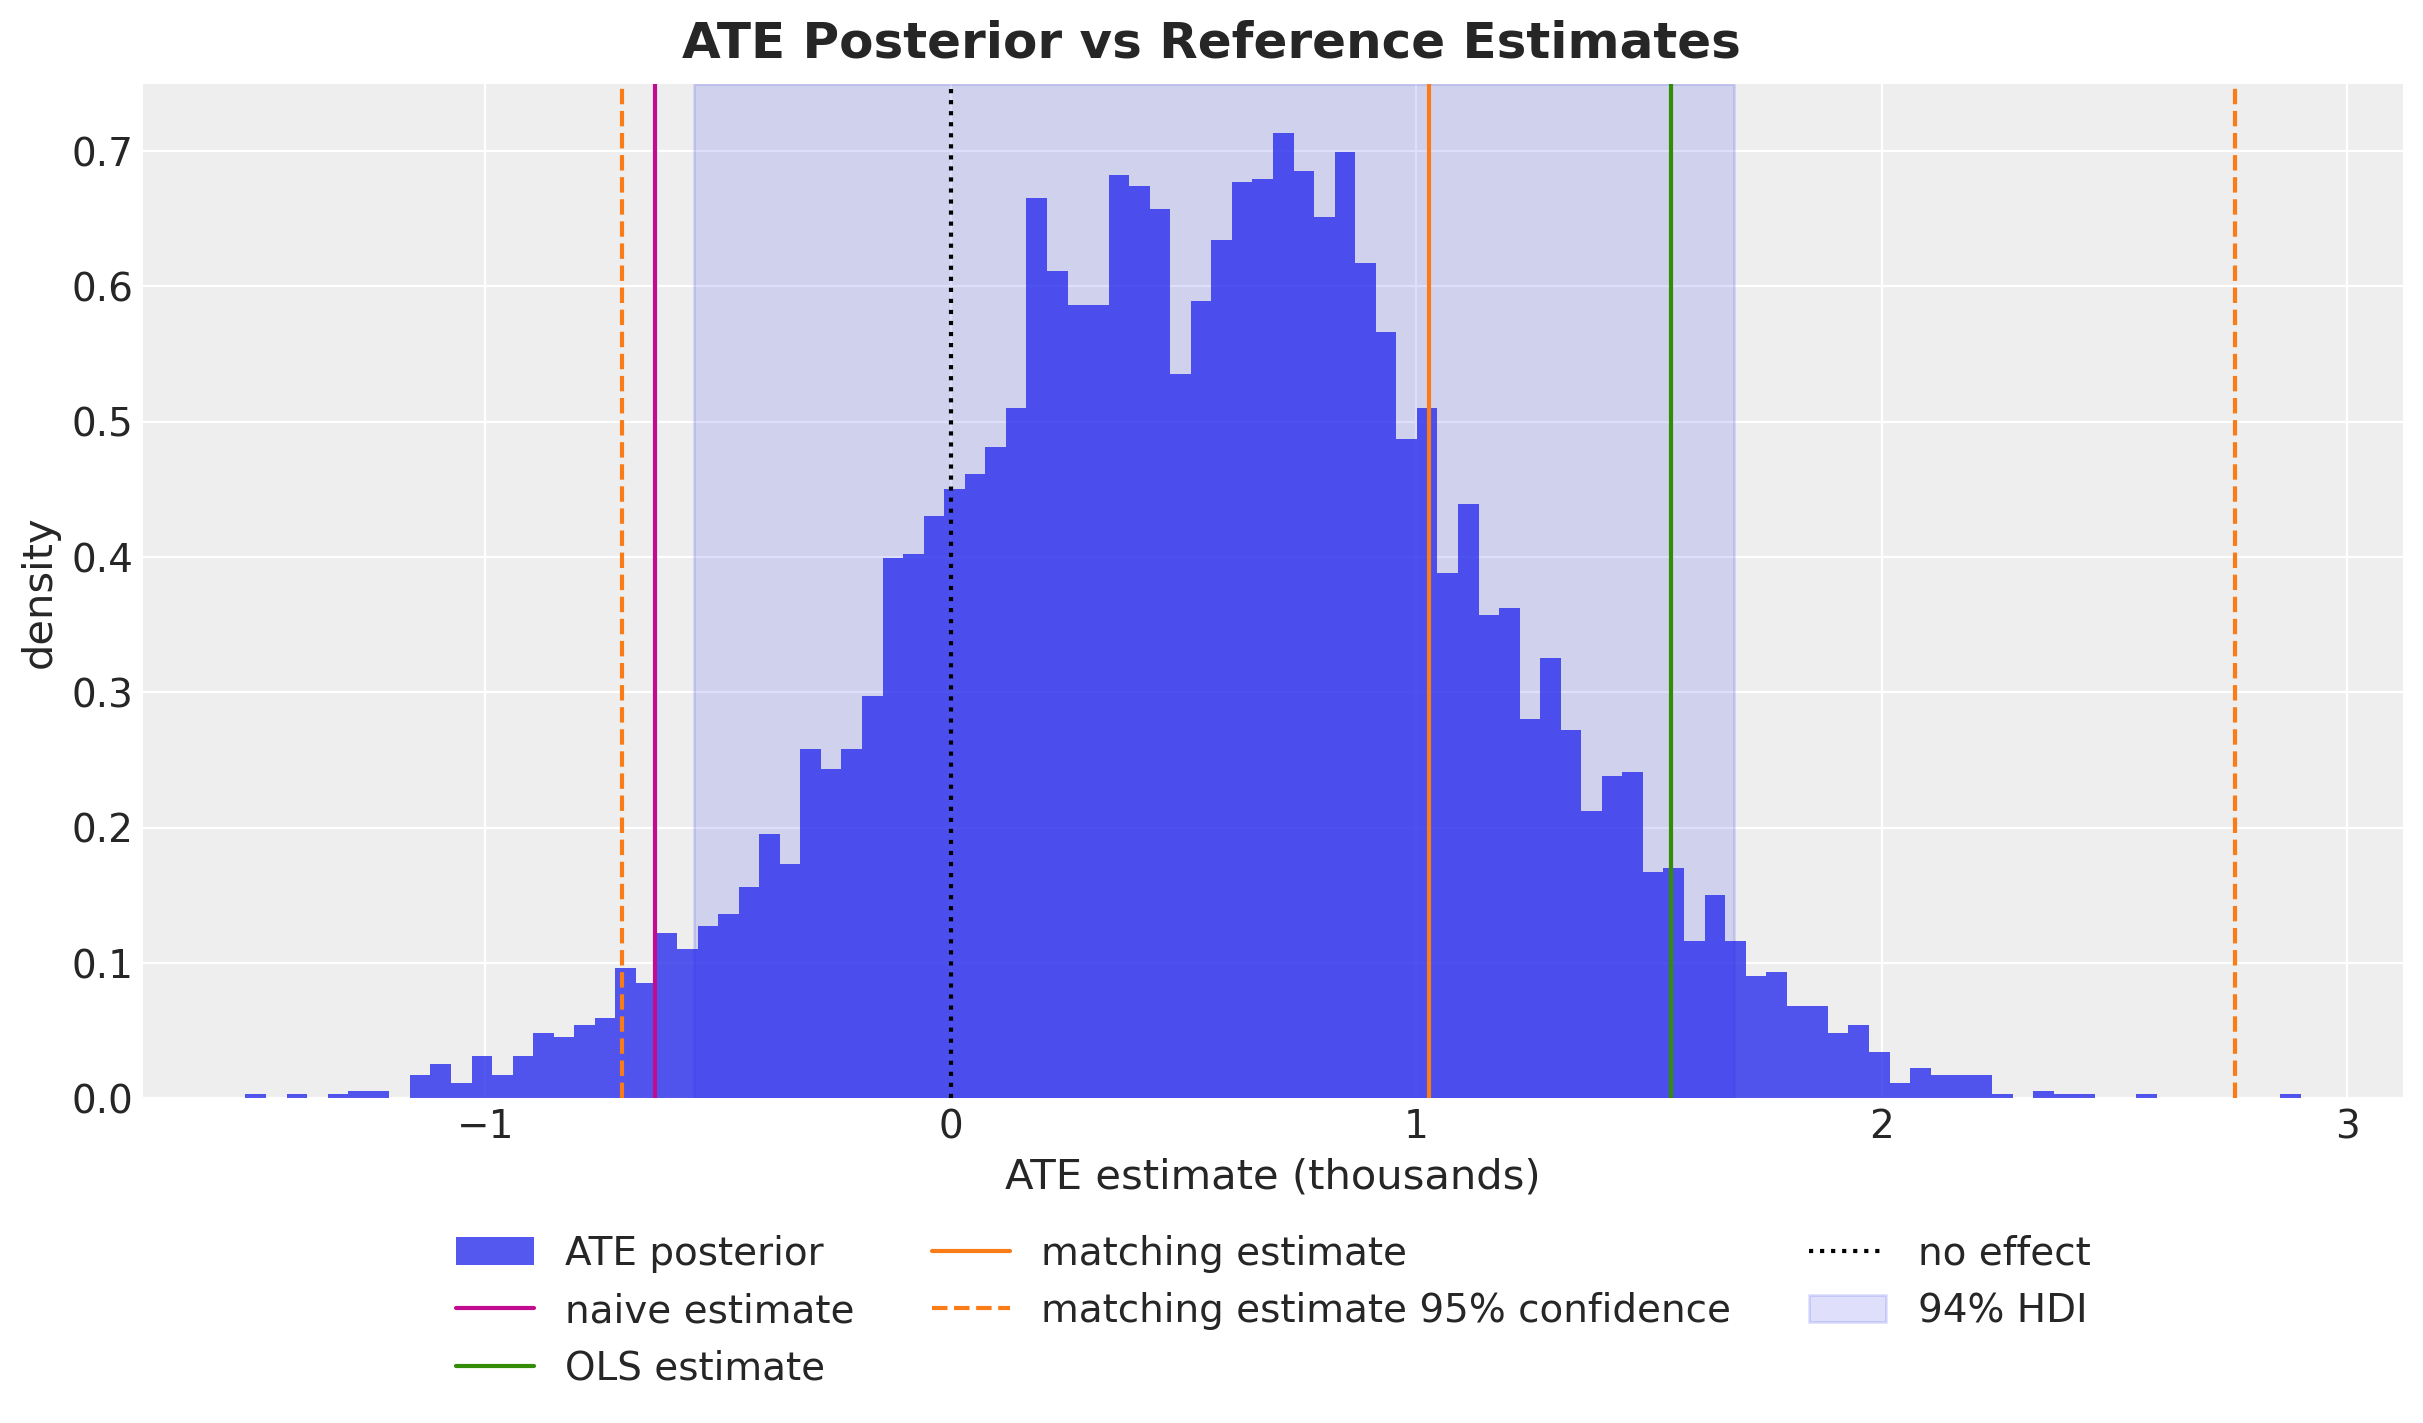

In [26]:
ate_draws = ate.draws()
ate_hdi = ate.hdi(prob=HDI_PROB)

fig, ax = plt.subplots(figsize=(12, 7))
ax.hist(ate_draws, bins=100, color="C0", alpha=0.8, density=True, label="ATE posterior")
ax.axvline(naive_prediction, color="C3", label="naive estimate")
ax.axvline(blog_prediction_ols, color="C2", label="OLS estimate")
ax.axvline(blog_prediction_matching, color="C1", label="matching estimate")
ax.axvline(
    blog_prediction_matching_ci95[0],
    color="C1",
    linestyle="dashed",
    label="matching estimate 95% confidence",
)
ax.axvline(blog_prediction_matching_ci95[1], color="C1", linestyle="dashed")
ax.axvline(0, color="black", linestyle="dotted", label="no effect")
ax.axvspan(ate_hdi[0], ate_hdi[1], color="C0", alpha=0.15, label=f"{HDI_PROB:.0%} HDI")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=3)
ax.set(xlabel="ATE estimate (thousands)", ylabel="density")
fig.suptitle("ATE Posterior vs Reference Estimates", fontsize=18, fontweight="bold");

The posterior mean sits between the naive estimate and the published OLS and matching estimates, and the credible interval comfortably contains zero.

In [27]:
print(f"P(ATE > 0) = {ate.prob('> 0'):.3f}")

P(ATE > 0) = 0.822


This is the honest headline. The effect is positive in expectation, but the data do not rule out no effect at all. The previous post reached the same conclusion, and two independent checks later in this notebook will agree.

Finally, a forest plot comparing the coefficient route and the do-operator route side by side.

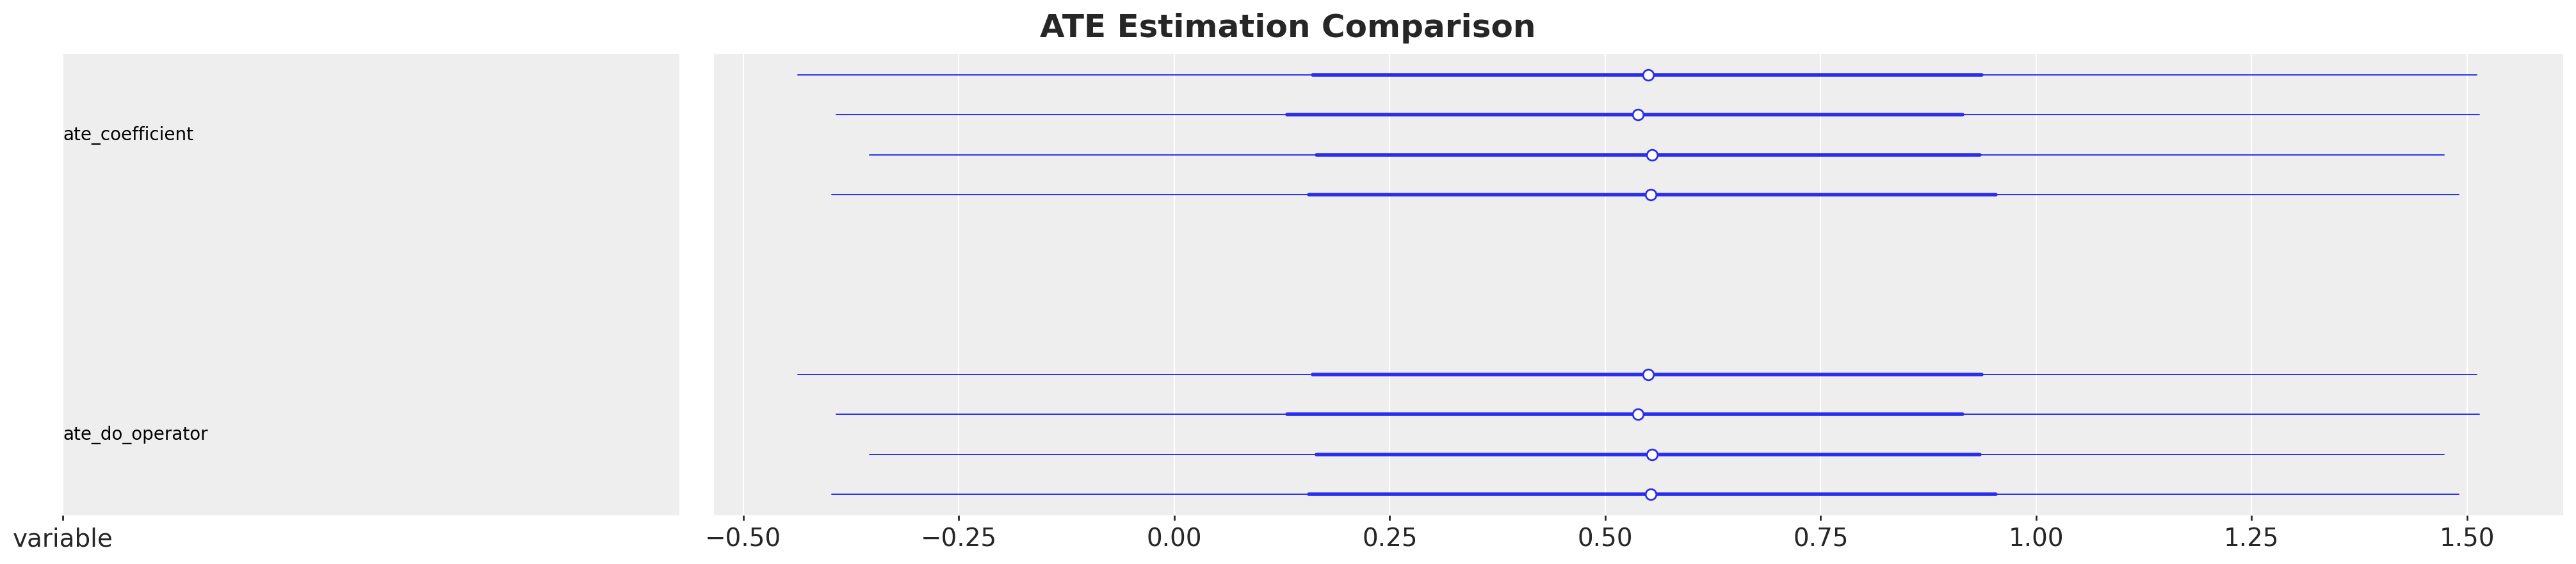

In [28]:
comparison_ds = xr.Dataset(
    {
        "ate_coefficient": coefficient_draws.drop_vars("re78_predictors"),
        "ate_do_operator": ate.dataset["re78"],
    }
)

pc = az.plot_forest(xr.DataTree(dataset=comparison_ds, name="posterior"))
pc.viz["figure"].item().suptitle(
    "ATE Estimation Comparison", fontsize=18, fontweight="bold"
);

## Structural Model or Regression Adjustment?

Our model does two things at once. It models how treatment was assigned (`treat ~ covariates`) and how earnings were generated (`re78 ~ treat + covariates`). But the backdoor criterion only requires the second one. If conditioning on the covariates blocks every confounding path, a plain outcome regression should recover the same ATE.

PathMC 0.3.0 added `adjustment_model()`, which reads the DAG, selects a minimal backdoor set, and builds the reduced single-equation model for you. It comes back unfitted, so you still call `.fit()` on it yourself.

In [29]:
default_prior_model = pathmc.model(
    f"""
    treat ~ {" + ".join(covariates_names)}
    re78 ~ treat + {" + ".join(covariates_names)}
    """,
    data=df,
    families={"treat": "bernoulli", "re78": "gaussian"},
)

adjustment_model = default_prior_model.adjustment_model("treat -> re78")

print(f"Reduced formula: {adjustment_model.formula}")
print(f"Adjustment set:  {adjustment_model.adjustment_set}")

Reduced formula: re78 ~ treat + age + black + education + hispanic + married + nodegree + re75


Adjustment set:  frozenset({'education', 'black', 'married', 'nodegree', 'age', 're75', 'hispanic'})


```{note}
We built that from a model with default priors on purpose. In PathMC 0.3.0, `adjustment_model()` raises whenever the parent model carries a custom prior on the outcome's coefficient vector, and the workaround its error message suggests cannot actually be reached. We reported this as [an issue](https://github.com/pymc-labs/pathmc/issues/463).
```

Since we want the previous post's priors, we build the reduced equation directly as its own model. It is a one-line spec anyway.

In [30]:
adjusted_model = pathmc.model(
    f"re78 ~ b*treat + {' + '.join(f'c_{v}*{v}' for v in covariates_names)}",
    data=df,
    families={"re78": "gaussian"},
    priors={
        "beta_re78": Prior(
            "Normal", mu=0, sigma=[10.0] + [1.0] * n_re78_slopes, dims="re78_predictors"
        ),
        "sigma_re78": Prior("HalfNormal", sigma=10.0),
    },
)

adjusted_idata = adjusted_model.fit(
    draws=2_000,
    tune=1_000,
    chains=4,
    random_seed=seed,
)

adjusted_ate = adjusted_model.ate(outcome="re78", treatment="treat", values=(0.0, 1.0))

NUTS[nutpie]: [beta_re78, sigma_re78]


Output()

In [31]:
pd.concat(
    [
        ate.summary(prob=HDI_PROB).assign(model="structural SCM"),
        adjusted_ate.summary(prob=HDI_PROB).assign(model="regression adjustment"),
    ]
).set_index("model").round(3)

,outcome,treatment,mean,sd,hdi_3%,hdi_97%,p(>0)
model,,,,,,,
structural SCM,re78,treat,0.549,0.588,-0.552,1.683,0.822
regression adjustment,re78,treat,0.540,0.589,-0.588,1.611,0.819


The two estimates are practically identical, and that is the lesson rather than a coincidence. **Modeling the treatment assignment mechanism does not improve a backdoor-adjusted ATE.** The propensity equation contributes nothing to this particular estimand.

So why write the full structural model at all? Because it buys you things the reduced regression cannot offer. You get the propensity model itself if you want to inspect or reuse it, you can intervene on *any* node in the graph rather than just the designated treatment, and you can ask about mediation and path-specific effects. If the ATE is genuinely all you need and your adjustment set is valid, the one-line regression is the honest answer.

## Marginal Effects and Contrasts

PathMC 0.3.0 also introduced an interpret layer modeled on [marginaleffects](https://marginaleffects.com/): `predictions()`, `comparisons()`, and `slopes()`, all sharing a common result type.

Before that, a quick payoff from having labeled the coefficients in the spec. `effects_summary()` reports them by name rather than by position.

In [32]:
model.effects_summary().round(3)

,mean,sd,hdi_3%,hdi_97%
name,,,,
b,0.549,0.588,-0.552,1.683
c_education,1.150,0.335,0.549,1.794
c_age,0.514,0.287,-0.027,1.043
c_re75,1.531,0.288,0.989,2.068
c_black,-0.937,0.586,-2.004,0.188
c_hispanic,0.236,0.694,-1.109,1.513
c_married,0.776,0.567,-0.341,1.811
c_nodegree,-0.127,0.621,-1.285,1.052


The ATE is an additive contrast. Sometimes a multiplicative one is more natural, especially for earnings.

In [33]:
for kind in ["diff", "ratio", "lift"]:
    print(model.comparisons(outcome="re78", variable="treat", comparison=kind))

ATE: treat→re78  mean=0.55  94% HDI=[-0.55, 1.68]
ratio: treat→re78  mean=1.10  94% HDI=[0.88, 1.31]


lift: treat→re78  mean=0.10  94% HDI=[-0.12, 0.31]


The ratio says the program multiplies expected earnings by roughly $1.1$, with an interval that comfortably includes $1$. Same conclusion as the difference, expressed on a scale that may be easier to communicate.

`slopes()` gives marginal effects for continuous variables. Here is the effect of prior earnings on later earnings, first as a derivative and then as an elasticity.

In [34]:
print(model.slopes(outcome="re78", wrt="re75", slope="dydx"))
print(model.slopes(outcome="re78", wrt="re75", slope="eyex"))

dydx: re75→re78  mean=1.53  94% HDI=[1.01, 2.09]


eyex: re75→re78  mean=0.12  94% HDI=[0.08, 0.15]


The elasticity reads as a percentage: a $1\%$ increase in 1975 earnings is associated with roughly a $0.12\%$ increase in 1978 earnings.

Finally, `datagrid()` plus `predictions()` lets us trace counterfactual outcomes across a covariate. We build a grid over `re75` with the other covariates held at their means, then predict under both interventions.

In [35]:
re75_grid = np.linspace(df["re75"].min(), df["re75"].quantile(0.95), 25)
newdata = model.datagrid(re75=list(re75_grid))

predictions = {
    treat_value: model.predictions(
        outcome="re78", set={"treat": treat_value}, newdata=newdata
    ).dataset["re78"]
    for treat_value in (0.0, 1.0)
}

Note that we pass the intervention through `set=` rather than by editing the grid. `treat` is an endogenous node, so its value is generated by its own structural equation unless we explicitly intervene on it. Setting a `treat` column in `newdata` would be silently ignored.

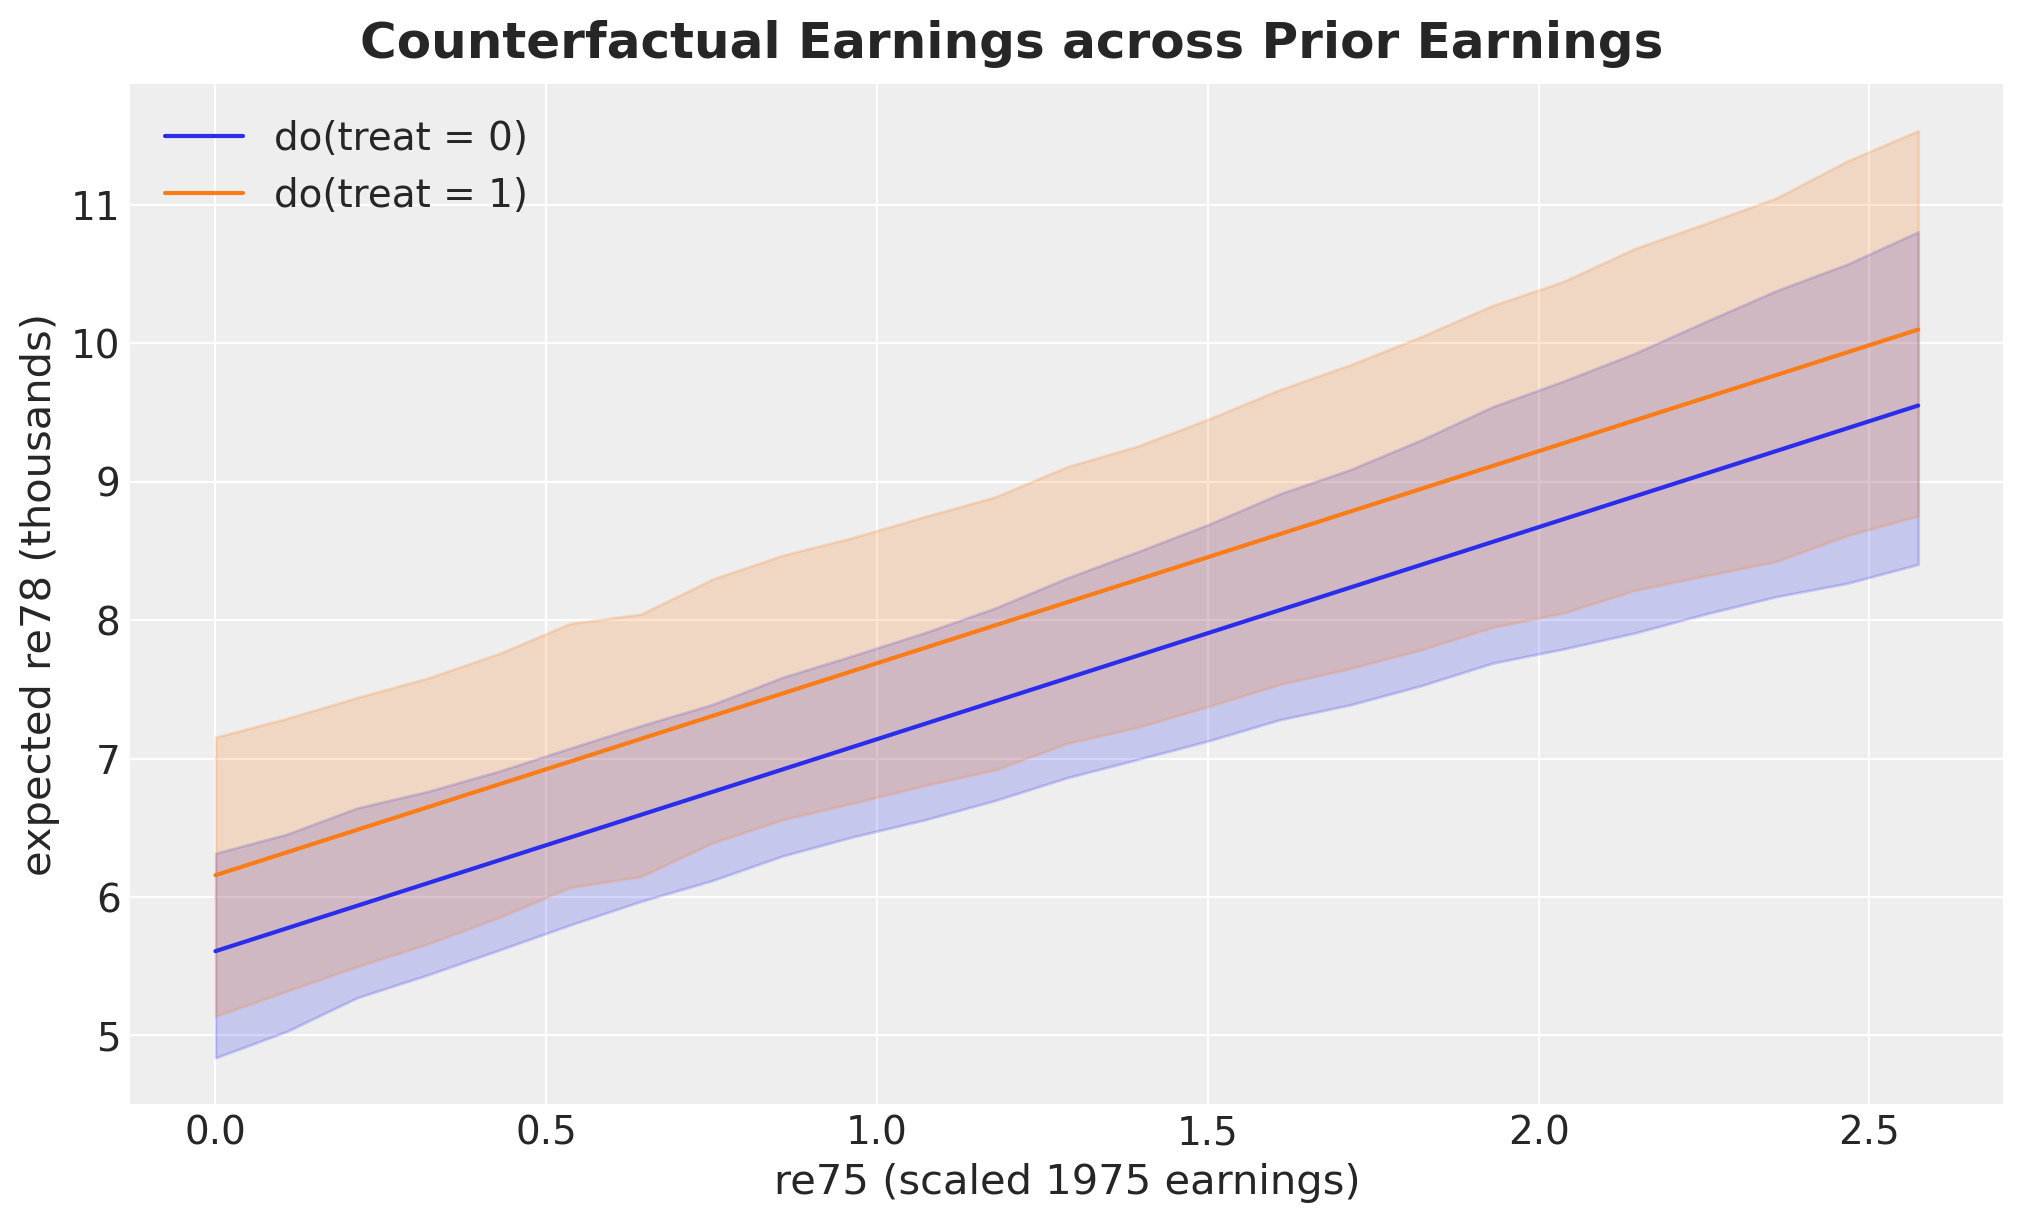

In [36]:
fig, ax = plt.subplots()

for treat_value, color in zip([0.0, 1.0], ["C0", "C1"], strict=True):
    preds = predictions[treat_value]
    mean = preds.mean(dim=("chain", "draw")).to_numpy()
    hdi = az.hdi(preds.to_numpy().reshape(-1, len(re75_grid)).T, prob=HDI_PROB)
    ax.plot(re75_grid, mean, color=color, label=f"do(treat = {treat_value:.0f})")
    ax.fill_between(re75_grid, hdi[:, 0], hdi[:, 1], color=color, alpha=0.2)

ax.legend(loc="upper left")
ax.set(
    xlabel="re75 (scaled 1975 earnings)",
    ylabel="expected re78 (thousands)",
)
fig.suptitle(
    "Counterfactual Earnings across Prior Earnings", fontsize=18, fontweight="bold"
);

The two curves are parallel, and the constant vertical gap between them *is* the ATE. That is a direct visual consequence of a linear model with no interaction between treatment and covariates: the treatment effect cannot vary with anything.

It also explains something that otherwise looks like a bug. Asking for a conditional effect returns exactly the ATE.

In [37]:
print(model.comparisons(outcome="re78", variable="treat", conditional={"re75": 1.0}))

ATE: treat→re78  mean=0.55  94% HDI=[-0.55, 1.68]


The conditional argument is being honored. It is the model that has no room for heterogeneity. Recovering a treatment effect that varies by subgroup requires interaction terms in the spec, which the DSL supports with the `treat:re75` syntax.

## What PathMC Does Not Cover

The previous post did not stop at the linear model. It went on to fit a Gamma likelihood with a softplus link, precisely because the linear model puts prior and posterior mass on negative earnings. That model cannot be written in PathMC today.

PathMC supports a fixed set of families (`gaussian`, `studentt`, `bernoulli`, `poisson`, `negbinomial`, `latent_normal`), and each family has a hard-coded link. There is no Gamma family, there is no `link=` argument, and there is no hook for registering one. The `register_transform` mechanism transforms *predictors* rather than the response, so it does not help. As noted earlier, an unrecognized family string silently becomes Gaussian.

We opened two issues upstream while writing this notebook: [#464](https://github.com/pymc-labs/pathmc/issues/464) for the Gamma family, selectable links, and family validation, and [#463](https://github.com/pymc-labs/pathmc/issues/463) for the `adjustment_model()` prior bug encountered above.

For the Gamma model itself, see the [previous post](https://juanitorduz.github.io/intro_causal_inference_ppl_pymc/), where writing PyMC by hand is exactly what makes it possible. This is the real trade-off with a DSL: it is excellent inside its design space and unyielding outside it.

## Refutation

A causal estimate should survive attempts to break it. PathMC ships two.

The placebo test permutes the treatment column, destroying any real relationship with the outcome, and re-fits. A sound pipeline should find nothing.

In [38]:
model.refute_placebo(
    outcome="re78",
    treatment="treat",
    n_permutations=4,
    random_seed=seed,
    sample_kwargs={"draws": 500, "tune": 500, "chains": 2, "progressbar": False},
)

NUTS[nutpie]: [beta_re78, beta_treat, sigma_re78]


NUTS[nutpie]: [beta_re78, beta_treat, sigma_re78]


NUTS[nutpie]: [beta_re78, beta_treat, sigma_re78]


NUTS[nutpie]: [beta_re78, beta_treat, sigma_re78]


NUTS[nutpie]: [mu_null, tau_het, z]


Sampling: [theta_new]


Placebo test,✓ Pass — the placebo null straddles zero.
Real effect,⚠ Not distinguishable — the observed effect is consistent with placebo noise.
Placebo bias μ_null,"0.1299 [-0.5252, 0.7843]"
Structural volatility τ_het,0.3729
Observed ATE,"0.5487 [-0.5524, 1.6835]"
Calibration,"z = 0.520, p_tail = 0.2510"
Permutations,4


There are two verdicts here and they answer different questions.

The placebo test itself **passes**: shuffled treatment yields a null effect near zero, so our estimation pipeline is not manufacturing signal out of noise. That is the property being tested, and it holds.

The second verdict reports that the real ATE **does not separate** from that placebo null. Given that the ATE's credible interval already contained zero and $P(\text{ATE} > 0) \approx 0.82$, this is not new information, but it is a useful independent confirmation. A refutation check that reported a clean survival here would have been the surprising outcome.

## Sensitivity to Unmeasured Confounding

Every result so far rests on an assumption we cannot test: that the seven covariates are *all* the confounders. If some unmeasured variable $U$ influences both program participation and earnings, our estimate absorbs its bias.

Sensitivity analysis reframes the untestable question into a quantitative one, following the [PathMC sensitivity example](https://pathmc.pymc-labs.com/docs/examples/identification/sensitivity.html). Suppose $U$ has effect $\gamma$ on the treatment and $\delta$ on the outcome. Under a first-order omitted-variable-bias model, the bias is the product $\gamma \times \delta$, so

$$\text{adjusted ATE} = \text{observed ATE} - \gamma \times \delta$$

The question becomes: how large would $\gamma \times \delta$ have to be to change our conclusion?

In [39]:
sensitivity = model.sensitivity(outcome="re78", treatment="treat")

sensitivity

Observed ATE,"0.5487 [-0.5524, 1.6835] (94% HDI)"
Tipping point,γ × δ = 0.5487
Symmetric example,"γ = 0.7407, δ = 0.7407 would nullify the effect"


The tipping point equals the observed ATE, and it always will. Under this bias model the product that drives the adjusted ATE to zero is by definition the observed ATE itself, so the number is a restatement rather than a discovery. The informative content is what that magnitude means in context, which is what the contour plot and the calibration below provide.

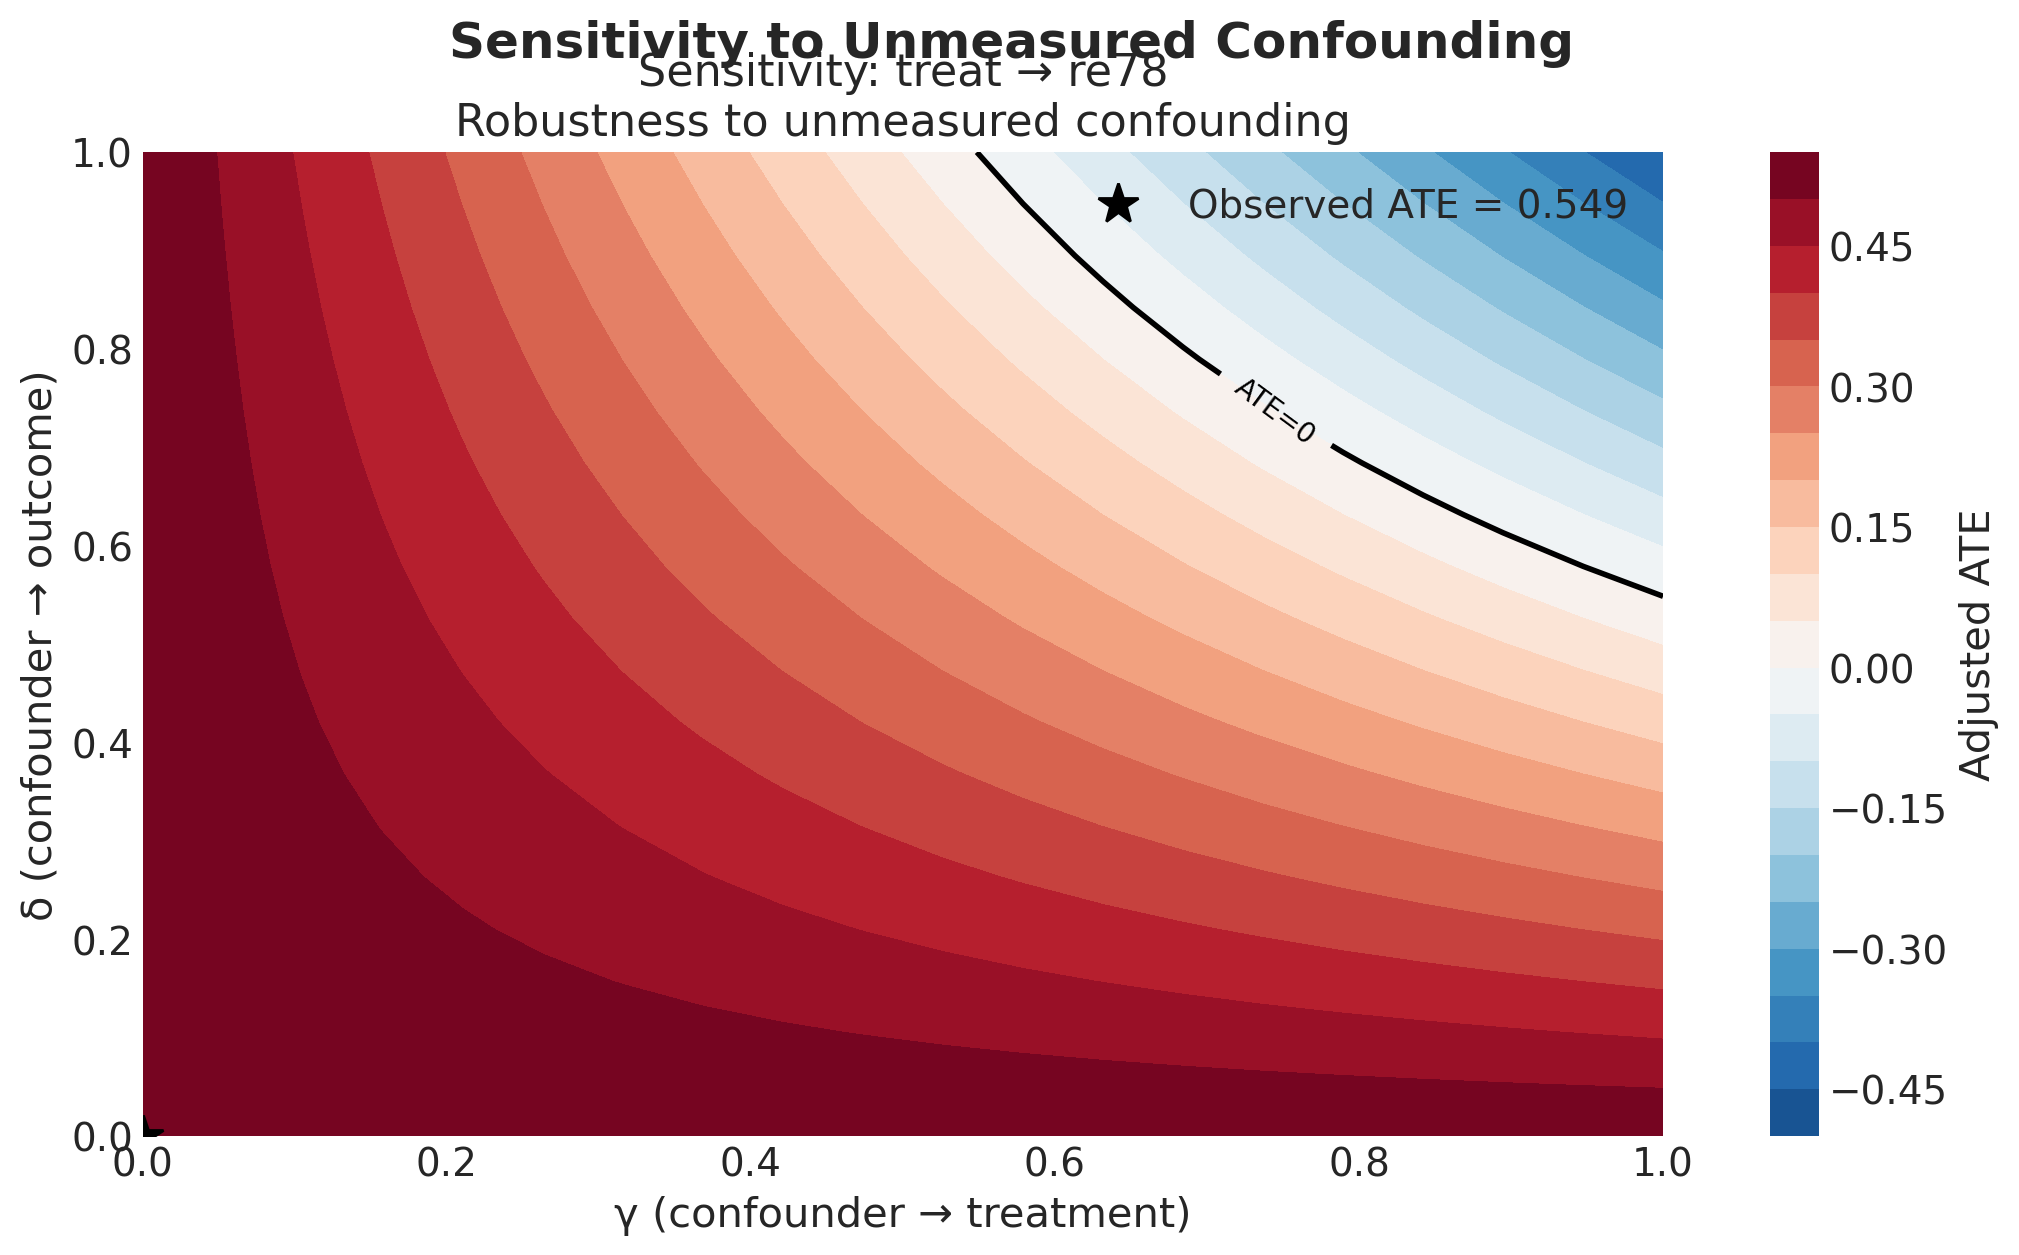

In [40]:
fig, ax = plt.subplots(figsize=(10, 6))
sensitivity.plot(ax=ax)
fig.suptitle(
    "Sensitivity to Unmeasured Confounding", fontsize=18, fontweight="bold", y=1.02
);

The x-axis is $\gamma$, the y-axis is $\delta$, and the black contour marks where the adjusted ATE crosses zero. Everything below and to the left preserves a positive effect.

To judge whether that boundary is far away or close, we calibrate against the covariates we *did* measure. A symmetric confounder sitting exactly on the tipping line would need $\gamma \approx \delta \approx \sqrt{\text{tipping point}}$.

In [41]:
symmetric_strength = np.sqrt(sensitivity.tipping_point)

print(f"Tipping point (gamma x delta): {sensitivity.tipping_point:.3f}")
print(f"Symmetric confounder strength: {symmetric_strength:.3f}")

Tipping point (gamma x delta): 0.549
Symmetric confounder strength: 0.741


We can do better than that summary number. Every covariate in the model already has both a $\gamma$ (its estimated effect on treatment) and a $\delta$ (its estimated effect on earnings). So for each one we can compute the confounding product it *would* have contributed had we simply failed to measure it, and compare that against the tipping point.

In [42]:
posterior = idata["posterior"]
gamma = posterior["beta_treat"].mean(dim=("chain", "draw")).to_pandas()
delta = posterior["beta_re78"].mean(dim=("chain", "draw")).to_pandas()

calibration = pd.DataFrame(
    {
        "gamma_on_treat": gamma[covariates_names],
        "delta_on_re78": delta[covariates_names],
    }
)
calibration["abs_gamma_x_delta"] = (
    calibration["gamma_on_treat"] * calibration["delta_on_re78"]
).abs()
calibration["exceeds_tipping_point"] = (
    calibration["abs_gamma_x_delta"] > sensitivity.tipping_point
)

calibration.sort_values("abs_gamma_x_delta", ascending=False).round(3)

,gamma_on_treat,delta_on_re78,abs_gamma_x_delta,exceeds_tipping_point
black,2.915,-0.937,2.731,True
married,-0.870,0.776,0.675,True
education,0.349,1.150,0.401,False
hispanic,0.700,0.236,0.165,False
nodegree,0.704,-0.127,0.090,False
re75,-0.048,1.531,0.073,False
age,0.077,0.514,0.040,False


This is the answer to "how strong is strong". Two of the seven covariates would on their own have produced bias larger than the entire estimated effect, and `black` would have produced roughly five times it. A third, `education`, lands within striking distance. Only the weaker covariates fall clearly below the line.

One caveat on reading the table: $\gamma$ lives on the logit scale of the treatment equation while $\delta$ is in thousands of dollars, and the bias model assumes a unit-variance confounder acting linearly on both. The products are therefore a rough guide to magnitude rather than an exact bias decomposition. The qualitative conclusion is robust to that looseness.

So the estimate is fragile, and we should say so plainly. It does not mean the effect is zero. It means the causal claim leans heavily on having measured the right things, and that a single unobserved variable of a kind we already know exists in this data would be enough to erase it. This is the third independent line of evidence pointing the same way, alongside the credible interval and the placebo refutation.

## Conclusion

We set out to rebuild a hand-rolled PyMC structural causal model in PathMC and check that the answers matched. They did, to machine precision, and the coefficient posterior landed on top of the previous post's to within Monte Carlo error.

### What the DSL gave us

The model itself went from roughly forty lines of PyMC to two lines of spec. That is pleasant but it is not the real gain. The real gain is everything that came after: backdoor adjustment sets read off the graph, implied conditional independences enumerated and tested, DAG falsification, placebo refutation, marginal effects and elasticities, and a sensitivity analysis. Each of those would have been a project in the hand-rolled version. Here each was one method call.

The comparison between the structural model and the plain adjustment regression was also clarifying. They agreed, as the backdoor criterion says they must, which is a good reminder that modeling more of the world does not automatically buy a better estimate of one particular effect.

### What it cost

The Gamma likelihood with a softplus link, which was half of the previous post, simply cannot be expressed. Families and links are a closed set. And the silent Gaussian fallback for unrecognized families is a genuine trap, since the failure mode is a model that runs perfectly and answers a different question than the one you asked.

This is the usual bargain with a domain-specific language, and it is a reasonable one. Use PathMC when your model lives inside its design space, and reach for raw PyMC when it does not. The two compose more easily than you might expect, since `model.pymc_model` hands you the compiled model whenever you want to inspect it.

### What we learned about the data

Very little that is encouraging, and that is worth stating clearly. The estimated effect of the training program on 1978 earnings is positive in expectation, around $0.55$ thousand dollars, with $P(\text{ATE} > 0) \approx 0.82$ and a credible interval that comfortably contains zero. The placebo refutation could not distinguish it from a null effect, and the sensitivity analysis showed that an unmeasured confounder no stronger than several covariates we already measured would be enough to overturn it.

None of that says the program did not work. It says this dataset, under this model, cannot tell us with confidence that it did.

In [43]:
%reload_ext watermark
%watermark -n -u -v -iv -w

Last updated: Fri, 21 Aug 2026

Python implementation: CPython
Python version       : 3.14.7
IPython version      : 9.16.1

arviz      : 1.3.0
matplotlib : 3.10.9
numpy      : 2.4.6
pandas     : 3.0.5
pathmc     : 0.3.0
pymc_extras: 0.12.0
xarray     : 2026.7.0

Watermark: 2.6.0

